# CHES-related analysis

This notebook is dedicated to the processing and analysis of trends of the CHES variables. 
Focus identities and related variables: 
- LRGEN: general left-right positioning,
- Families: The ideologies that the parties subscribe to
- GAL-TAN: Positioning of political parties according to the libertarian - traditional axis. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv("../Sample/CHES-SI.tsv", sep="\t", encoding="utf-8")
cols = ["parlamint", "party_id", "party", "year", "lrgen", "galtan", "family", "seat"]
df = df[cols]
print(df.shape)
df.head()

(49, 8)


,parlamint,party_id,party,year,lrgen,galtan,family,seat
0,-,2909,AS,2006,4.6,2.6,7,0
1,-,2904,SLS-SMS,2010,6.8,7.8,4,5.6
2,DL,-,-,-,-,-,-,-
3,DLGV,-,-,-,-,-,-,-
4,DeSUS,2906,DeSUS,2002,3.4,5.8,9,4.4


In [3]:
#Parties in ParlaMint, but not in CHES: DL, DLGV, GAS, Konkretno, Lipa, NP, NeP
df = df[df["parlamint"]!="-"]
df = df[df["lrgen"] != "-"]

df.shape

(40, 8)

In [4]:
mapping={
    "1":"Radical Right", 
    "2":"Conservatives",
    "3":"Liberal", 
    "4":"Christian-Democratic",
    "5":"Socialist", 
    "6":"Radical Left", 
    "7":"Green", 
    "8":"Regionalist", 
    "9":"No family", 
    "10":"Confessional", 
    "11":"Agrarian/Center"
}

groups = {
    "ZL": "ZL/Levica",
    "Levica + ZL":"ZL/Levica",
    "Levica": "ZL/Levica",
    "AB":"ZaAB/ZaSLD/SAB",
    "ZaAB":"ZaAB/ZaSLD/SAB",
    "ZaSLD":"ZaAB/ZaSLD/SAB",
    "SAB" :"ZaAB/ZaSLD/SAB",
    "ZLSD":"ZLSD/SD",
    "SD":"ZLSD/SD",
    "SLS+SKD":"SLS+SKD/SLS",
    "SLS":"SLS+SKD/SLS", 
    "DLGV":"DLGV/DL", 
    "DL":"DLGV/DL",
    "SMC":"SMC/GAS/Konkretno",
    "Konkretno": "SMC/GAS/Konkretno"
}
df["family"] = df["family"].map(mapping).fillna(df["family"])
df["grouped_parties"] = df['parlamint'].replace(groups).fillna(df['parlamint'])

df.head()

,parlamint,party_id,party,year,lrgen,galtan,family,seat,grouped_parties
4,DeSUS,2906,DeSUS,2002,3.4,5.8,No family,4.4,DeSUS
5,DeSUS,2906,DeSUS,2006,3.2,4.5,No family,4.4,DeSUS
6,DeSUS,2906,DeSUS,2010,4.2,5.2,No family,7.8,DeSUS
7,DeSUS,2906,DeSUS,2014,4.2,5.3,No family,11.1,DeSUS
8,DeSUS,2906,DeSUS,2019,3.8,5.1,No family,5.7,DeSUS


# Distributions

### Family
(CHES Codebook definition) "FAMILY= classification was initially based on Hix and Lord (1997), except that we place confessional and agrarian parties in separate categories. Family association for parties in Central/Eastern Europe was based initially on Derksen classification (now incorporated in Wikipedia), triangulated by a) membership or aﬃliation with international and EU party associations, and b) self-identification. We update family codings based on ideological shifts or organizational changes."

In [5]:
#Check families
family_cols = ["parlamint", "grouped_parties", "party", "year", "family"]
family = df[family_cols]

family = family.sort_values(by=["grouped_parties", "year"])
family["family_change"] = family.groupby("grouped_parties")["family"].transform(lambda x: x != x.iloc[0])
changes = family[family["family_change"] != False]

print("Parties with family changes:")
print(changes)
#No changes in the Family during the years


Parties with family changes:
Empty DataFrame
Columns: [parlamint, grouped_parties, party, year, family, family_change]
Index: []


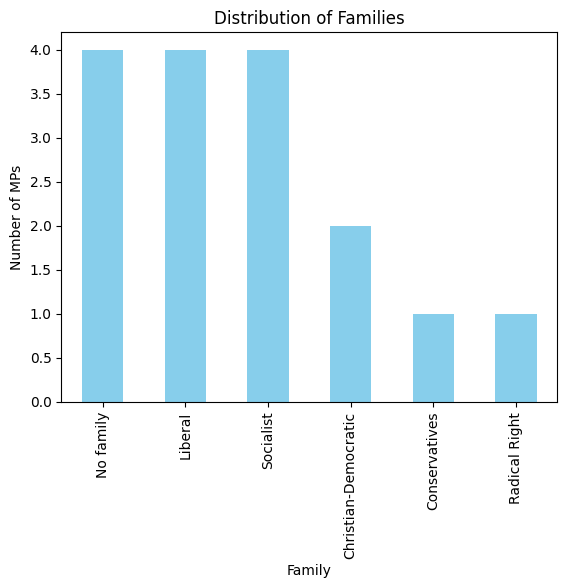

In [6]:
family = family.drop_duplicates(subset="grouped_parties").reset_index(drop=True)
family_counts = family["family"].value_counts()
family_counts.plot(kind='bar', color="skyblue")
plt.xlabel('Family')
plt.ylabel('Number of MPs')
plt.title('Distribution of Families')
plt.show()

In [7]:
col = ["parlamint", "grouped_parties", "family"]
family = family[col]
party_family = family.sort_values('grouped_parties')

latex_table = party_family.to_csv("../Results/Tables/Family.tsv", sep="\t", encoding="utf-8", index=False)

## Left-right political positioning
LRGEN= position of the party in YEAR in terms of its overall ideological stance.
0 = Extreme left .. 5 = Center.. 10 = Extreme right

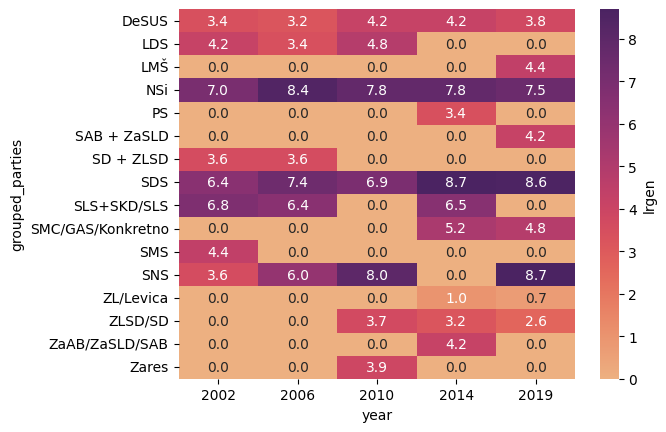

In [8]:
lrgen_pivot = df.pivot(index="grouped_parties", columns="year", values="lrgen").fillna(0)
lrgen_pivot = lrgen_pivot.astype(float)

sns.heatmap(
    lrgen_pivot, 
    annot=True, fmt=".1f", cmap="flare", cbar_kws={'label': 'lrgen'}
)
plt.show()

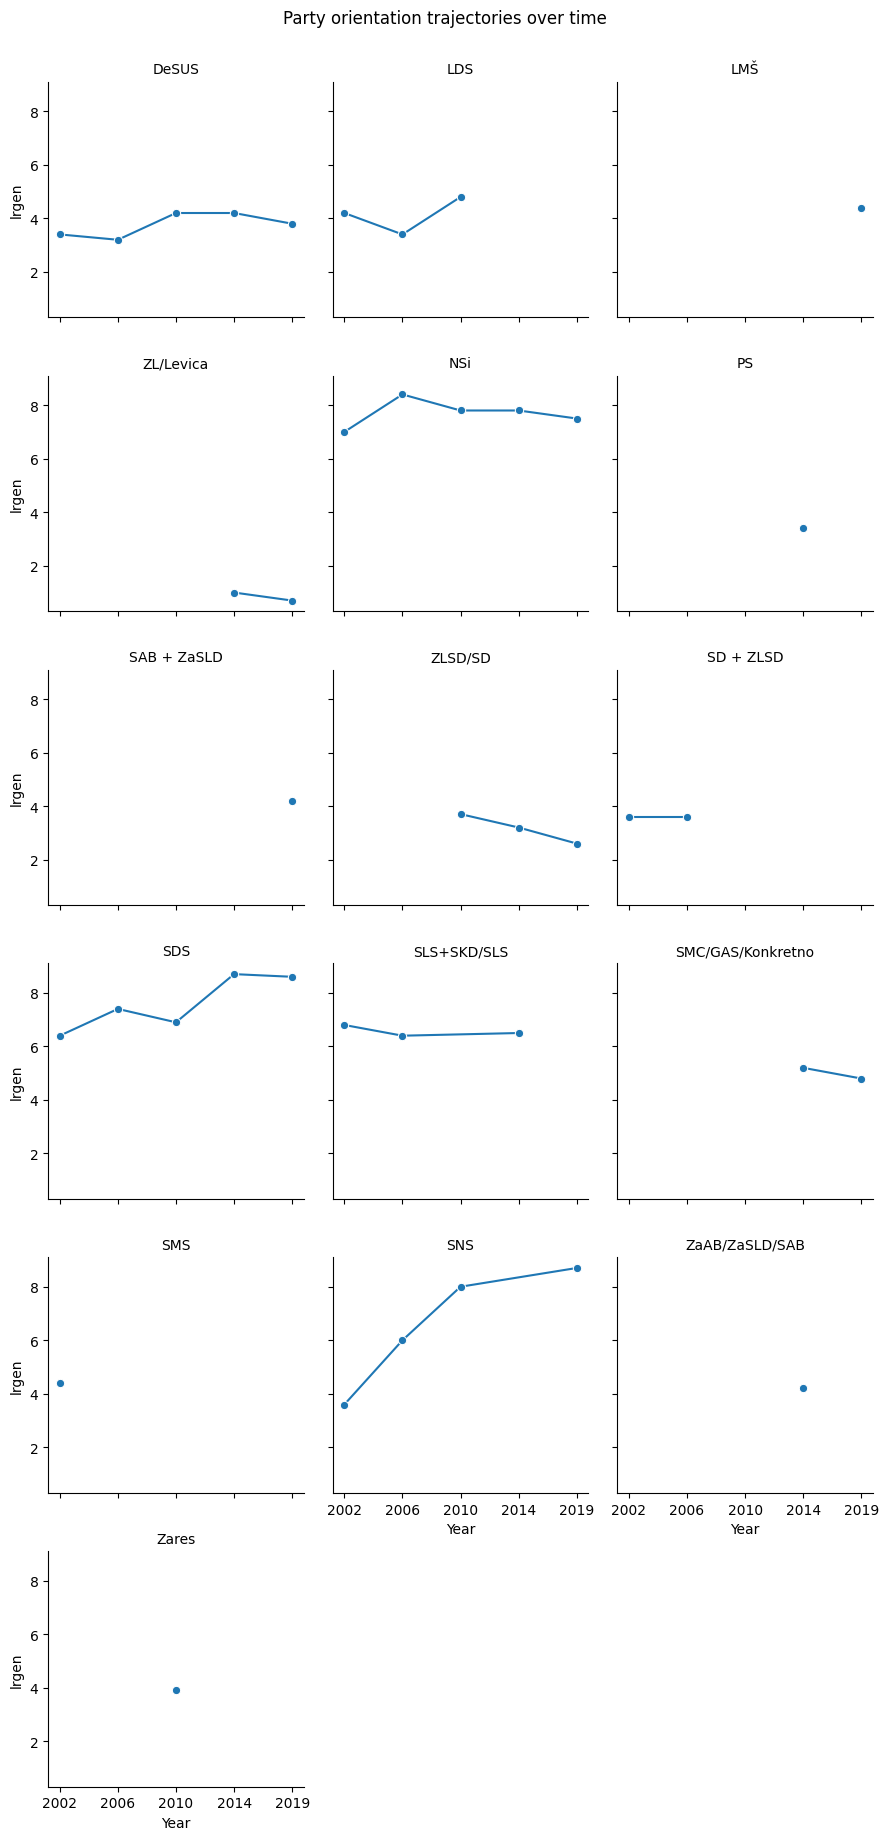

In [9]:
import numpy as np
df["lrgen"] = pd.to_numeric(df["lrgen"])
g = sns.FacetGrid(df, col="grouped_parties", col_wrap=3, height=3, sharey=True)
g.map_dataframe(sns.lineplot, x="year", y="lrgen", marker="o")

g.set_axis_labels("Year", "lrgen")
g.set_titles("{col_name}")
g.figure.suptitle("Party orientation trajectories over time", y=1.02)

plt.show()

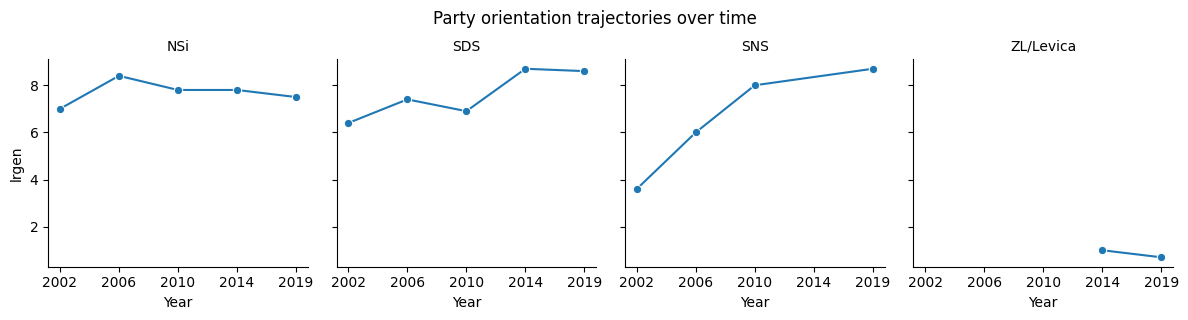

In [10]:
#Selection of most interesting patterns for Chapter III: 
select = ["SNS", "ZL/Levica", "SDS", "NSi"]
lrgen_select = df[df["grouped_parties"].isin(select)].sort_values(by=["grouped_parties","year"]).reset_index(drop=True)
lrgen_select

g = sns.FacetGrid(lrgen_select, col="grouped_parties", col_wrap=4, height=3, sharey=True)
g.map_dataframe(sns.lineplot, x="year", y="lrgen", marker="o")

g.set_axis_labels("Year", "lrgen")
g.set_titles("{col_name}")
g.figure.suptitle("Party orientation trajectories over time", y=1.05)

plt.show()

## Social and cultural positioning GAL-TAN 
Position of the party in 2019 in terms of their views on social and cultural values.
“Libertarian” or “postmaterialist” parties favor expanded personal freedoms, for example, abortion
rights, divorce, and same-sex marriage. “Traditional” or “authoritarian” parties reject these ideas
in favor of order, tradition, and stability, believing that the government should be a firm moral
authority on social and cultural issues.
0 = Libertarian/Postmaterialist .. 5 = center.. 10 = Traditional/Authoritarian

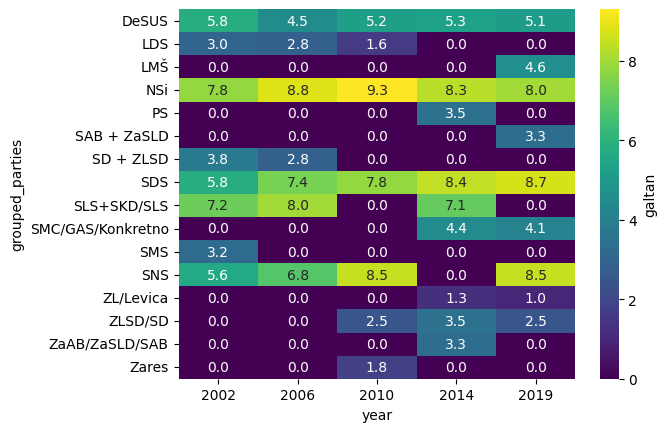

In [11]:
lrgen_pivot = df.pivot(index="grouped_parties", columns="year", values="galtan").fillna(0)
lrgen_pivot = lrgen_pivot.astype(float)

sns.heatmap(
    lrgen_pivot, 
    annot=True, fmt=".1f", cmap="viridis", cbar_kws={'label': 'galtan'},
)
plt.show()

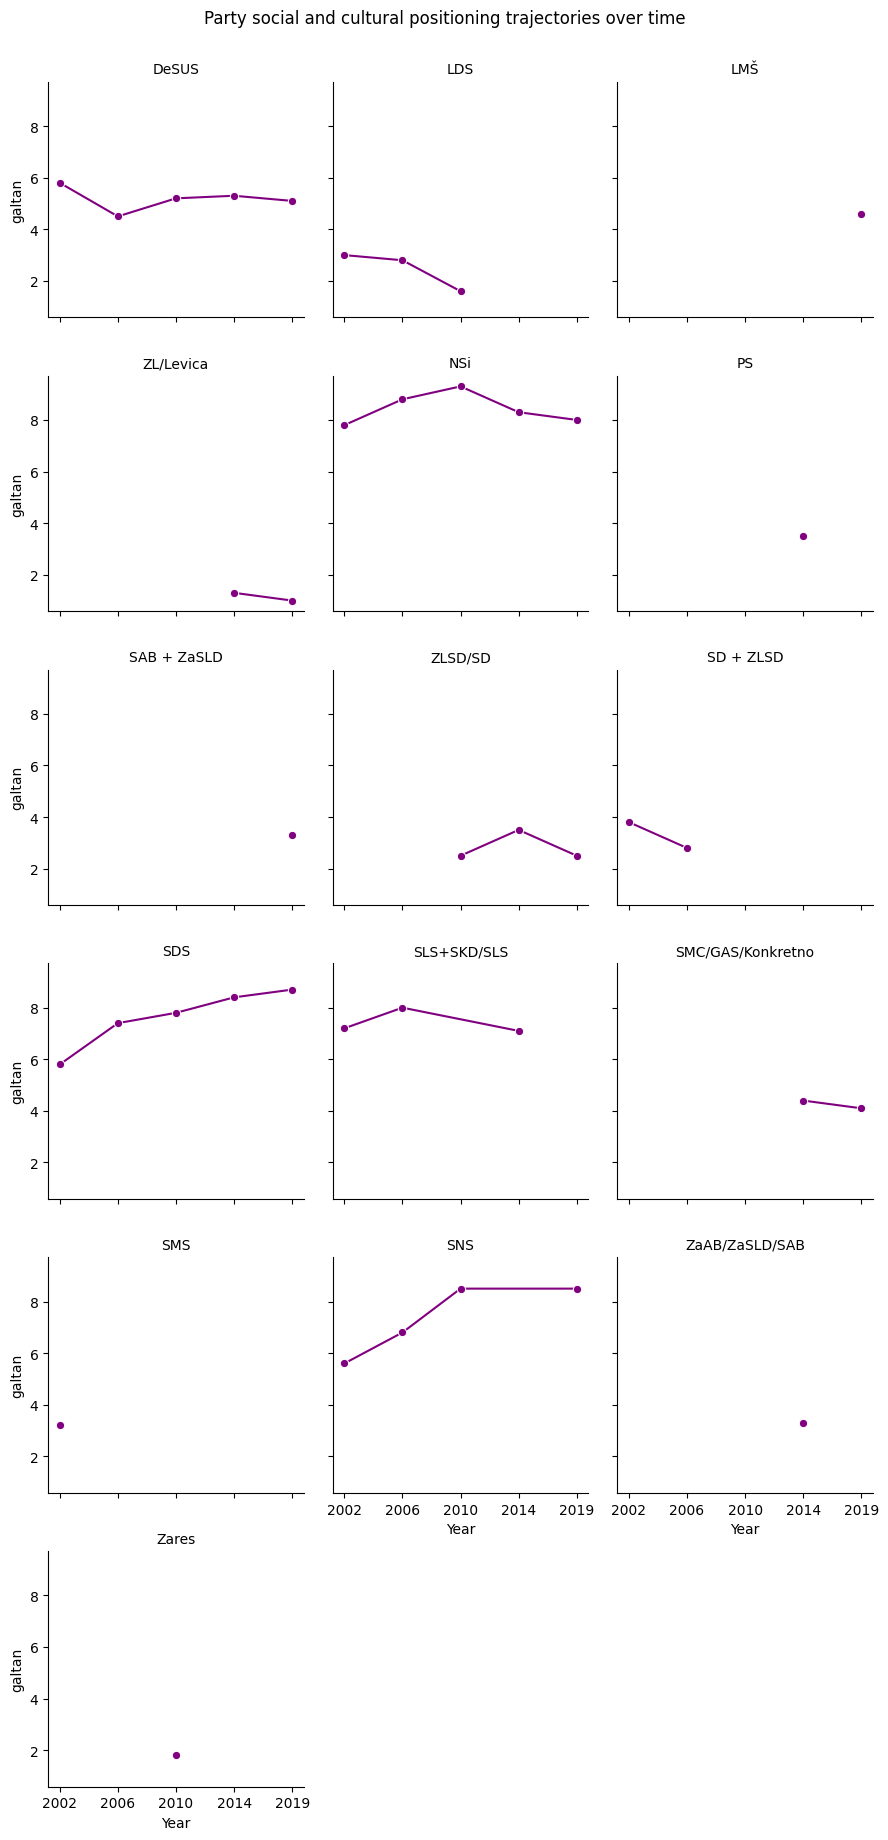

In [12]:
import numpy as np
df["galtan"] = pd.to_numeric(df["galtan"])
g = sns.FacetGrid(df, col="grouped_parties", col_wrap=3, height=3, sharey=True)
g.map_dataframe(sns.lineplot, x="year", y="galtan", marker="o", color="purple")

g.set_axis_labels("Year", "galtan")
g.set_titles("{col_name}")
g.figure.suptitle("Party social and cultural positioning trajectories over time", y=1.02)

plt.show()

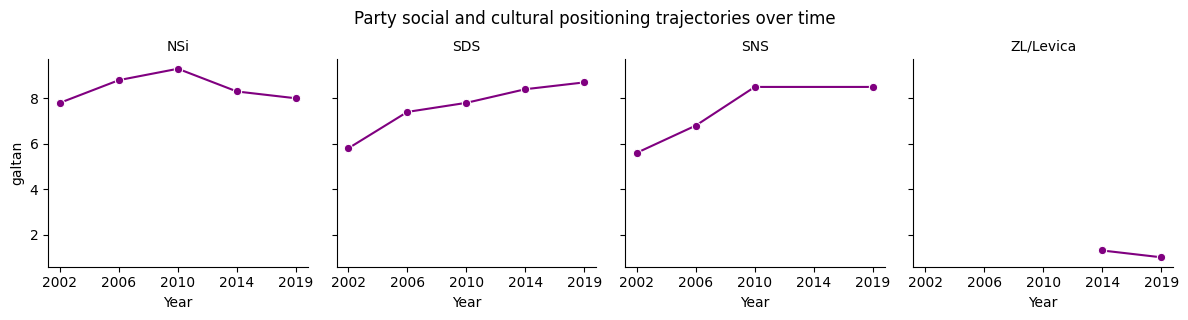

In [13]:
galtan_select = df[df["grouped_parties"].isin(select)].sort_values(by=["grouped_parties","year"]).reset_index(drop=True)
galtan_select
g = sns.FacetGrid(galtan_select, col="grouped_parties", col_wrap=4, height=3, sharey=True)
g.map_dataframe(sns.lineplot, x="year", y="galtan", marker="o", color="purple")

g.set_axis_labels("Year", "galtan")
g.set_titles("{col_name}")
g.figure.suptitle("Party social and cultural positioning trajectories over time", y=1.05)

plt.show()

### LRGEN and GALTAN comparison

In [16]:
#Inspection of the 2019 data
df["year"] = df["year"].astype(float)
years = [2002, 2006, 2010, 2014, 2019]
df["seat"] = df["seat"].astype(float)

color_map = {
    "Radical Right":"blue", 
    "Conservatives":"aquamarine",
    "Liberal":"yellow", 
    "Christian-Democratic":"cornflowerblue",
    "Socialist":"lightsalmon", 
    "Radical Left":"coral", 
    "Green":"green", 
    "Regionalist":"lightcyan", 
    "No family":"violet", 
    "Confessional":"aqua", 
    "Agrarian/Center":"violet"
}

for year in years:
    df_year = df[df["year"]== year]
    df_year = df_year[df_year["seat"]!=0]
    fig = px.scatter(
        df_year, 
        x="lrgen", 
        y="galtan", 
        size="seat",
        color="family", 
        hover_name="parlamint",
        color_discrete_map=color_map,   
        title=f"LRGEN/GALTAN comparison for {year}",
    )
    fig.update_layout(
        height=600,
        width=900,
        xaxis_title="LRGEN score", 
        yaxis_title="GALTAN score",
        xaxis=dict(range=[0, 10]), 
        yaxis=dict(range=[0, 10]),
        legend_title_text="Family"
    )
    fig.add_shape(
        type="line",
        x0=0,
        x1=10,
        y0=df_year["galtan"].mean(),
        y1=df_year["galtan"].mean(),
        line=dict(dash="dash", color="gray")
    )
    fig.add_shape(
        type="line",
        x0=df_year["lrgen"].mean(),
        x1=df_year["lrgen"].mean(),
        y0=0,
        y1=10,
        line=dict(dash="dash", color="gray")
    )

    for i, row in df_year.iterrows():
        fig.add_annotation(
            x=row["lrgen"],
            y=row["galtan"],
            text=row["parlamint"],
            showarrow=False,
            font=dict(size=10),
            xanchor="left",
            yanchor="bottom"
        )

    
    
    fig.show()
